## Training Log Visualization

This notebook parses `log.txt`, lists every recorded metric, and plots any subset across epochs. All helper functions live here, so you can tweak anything inline without touching other files.

In [16]:
from pathlib import Path
import math
import os
import re
from typing import Dict, Iterable, List, Tuple

FLOAT_RE = r"[-+]?\d*\.?\d+(?:e[-+]?\d+)?"
GENERAL_LINE = re.compile(rf"Epoch\s+(?P<epoch>\d+)/\d+\s*-\s*(?P<body>.*)")
V_LINE = re.compile(rf"Epoch\s+(?P<epoch>\d+)/\d+\s*-\s*(?P<body>.*)")
V_BLOCK = re.compile(rf"(v\d+)\s+Accuracy:\s*(?P<val>{FLOAT_RE})\s*(?:\((?P<extras>[^)]*)\))?")

mpl_cache = Path(".matplotlib_cache")
mpl_cache.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_cache))


def to_key(name: str) -> str:
    return re.sub(r"[^0-9a-zA-Z]+", "_", name).strip("_").lower()


def parse_general_line(line: str) -> Tuple[int, Dict[str, float]]:
    match = GENERAL_LINE.match(line)
    if not match:
        raise ValueError(f"Unrecognized log line: {line}")
    epoch = int(match.group("epoch"))
    metrics: Dict[str, float] = {}
    for chunk in match.group("body").split(","):
        chunk = chunk.strip()
        if not chunk or ":" not in chunk:
            continue
        key, value = chunk.split(":", 1)
        metrics[to_key(key)] = float(value)
    return epoch, metrics


def parse_v_line(expected_epoch: int, line: str) -> Dict[str, float]:
    match = V_LINE.match(line)
    if not match:
        raise ValueError(f"Unrecognized log line: {line}")
    epoch = int(match.group("epoch"))
    if epoch != expected_epoch:
        raise ValueError(f"Epoch mismatch between log lines: {expected_epoch} vs {epoch}")
    metrics: Dict[str, float] = {}
    for block in match.group("body").split(" - "):
        block = block.strip()
        if not block:
            continue
        block_match = V_BLOCK.match(block)
        if not block_match:
            continue
        name = block_match.group(1)
        metrics[to_key(f"{name} Accuracy")] = float(block_match.group("val"))
        extras = block_match.group("extras")
        if extras:
            for extra in extras.split(","):
                extra = extra.strip()
                if not extra or ":" not in extra:
                    continue
                k, v = extra.split(":", 1)
                metrics[to_key(f"{name}_{k.strip()}")] = float(v)
    return metrics


def parse_log_file(log_path: Path) -> List[Dict[str, float]]:
    lines = [line.strip() for line in log_path.read_text().splitlines() if line.strip()]
    records: List[Dict[str, float]] = []
    i = 0
    while i < len(lines):
        epoch, general_metrics = parse_general_line(lines[i])
        i += 1
        v_metrics: Dict[str, float] = {}
        if i < len(lines) and lines[i].startswith("Epoch"):
            v_metrics = parse_v_line(epoch, lines[i])
            i += 1
        record = {"epoch": float(epoch)}
        record.update(general_metrics)
        record.update(v_metrics)
        records.append(record)
    return records


def gather_columns(records: List[Dict[str, float]]) -> List[str]:
    columns = set()
    for record in records:
        columns.update(record.keys())
    columns.discard("epoch")
    return sorted(columns)


def build_series(records: List[Dict[str, float]], columns: Iterable[str]) -> Tuple[List[float], Dict[str, List[float]]]:
    epochs = [record["epoch"] for record in records]
    data: Dict[str, List[float]] = {}
    for column in columns:
        data[column] = [record.get(column, math.nan) for record in records]
    return epochs, data


def plot_metrics(epochs: List[float], data: Dict[str, List[float]], metrics: List[str], separate: bool = False):
    import matplotlib.pyplot as plt

    if separate:
        fig, axes = plt.subplots(len(metrics), 1, sharex=True, figsize=(12, 3 * len(metrics)))
        if len(metrics) == 1:
            axes = [axes]
        for ax, metric in zip(axes, metrics):
            ax.plot(epochs, data[metric], label=metric)
            ax.set_ylabel(metric)
            ax.grid(True, linestyle="--", alpha=0.3)
            ax.legend()
        axes[-1].set_xlabel("Epoch")
        fig.suptitle("Metrics over Epochs")
        plt.tight_layout()
        plt.show()
        return

    plt.figure(figsize=(12, 6))
    for metric in metrics:
        plt.plot(epochs, data[metric], label=metric)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title("Metrics over Epochs")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.show()

In [17]:
log_path = Path("log.txt")
records = parse_log_file(log_path)
available_metrics = gather_columns(records)
print(f"Loaded {len(records)} epochs from {log_path}.")
print(f"Detected {len(available_metrics)} metrics.")

Loaded 373 epochs from log.txt.
Detected 21 metrics.


In [18]:
# Inspect available metric keys.
for name in available_metrics:
    print(name)

attended_test_accuracy
attended_top5_accuracy
test_accuracy
test_loss
top5_accuracy
train_accuracy
train_loss
v100_accuracy
v100_att
v100_att_top5
v100_top5
v10_accuracy
v10_att
v2_accuracy
v2_att
v4_accuracy
v4_att
v50_accuracy
v50_att
v50_att_top5
v50_top5


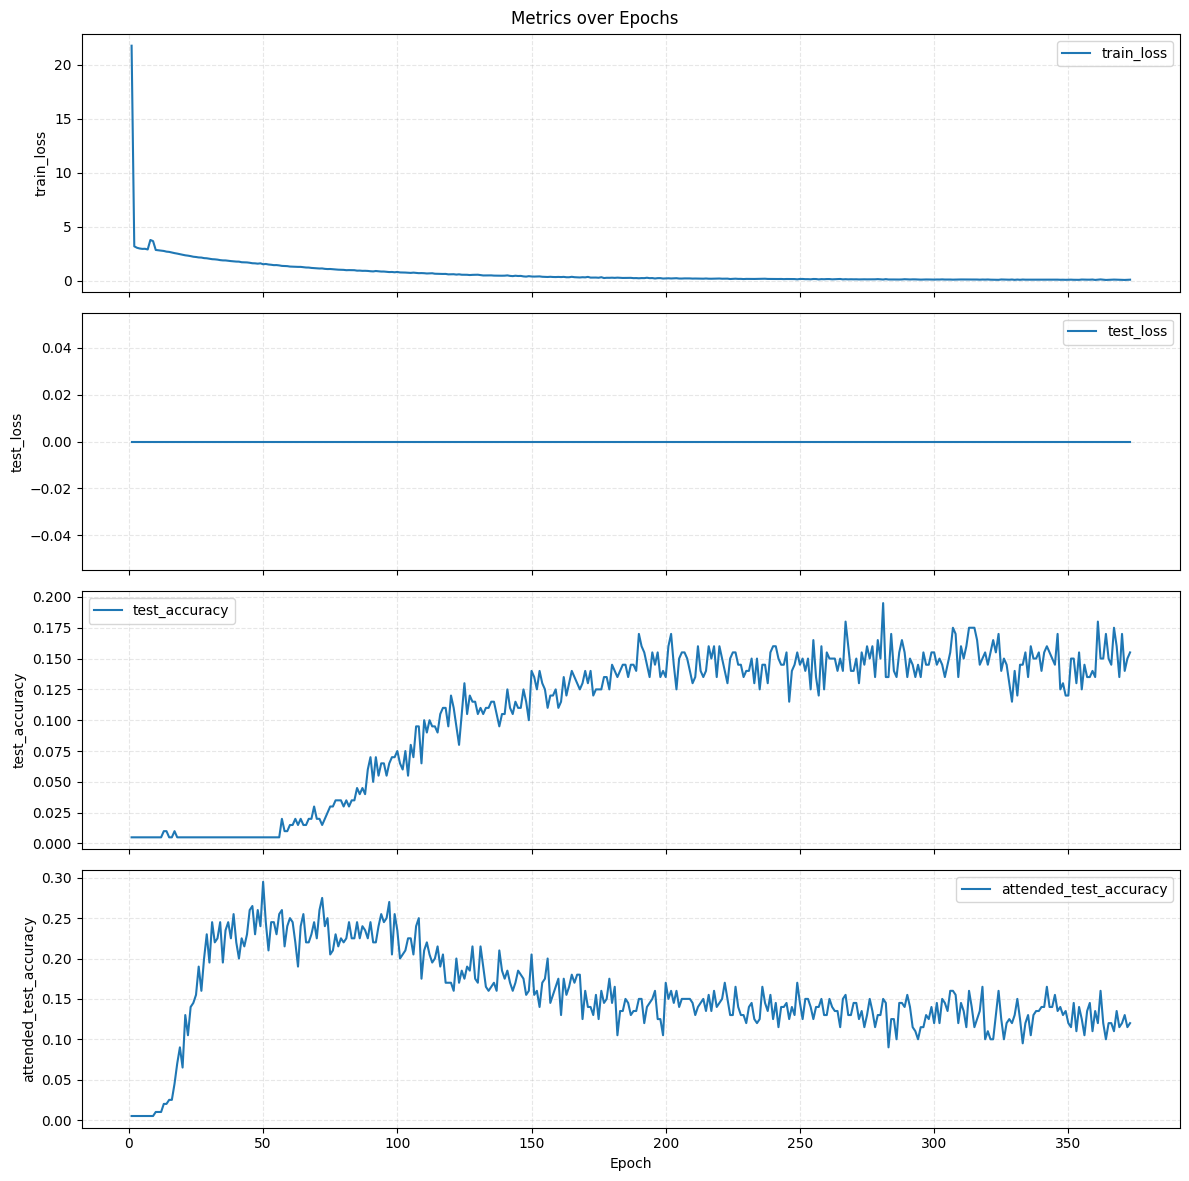

In [19]:
# Configure the epoch window and which metrics to visualize.
start_epoch = 1
end_epoch = 500
metrics_to_plot = [
    "train_loss",
    "test_loss",
    "test_accuracy",
    "attended_test_accuracy",
]

filtered_records = [rec for rec in records if start_epoch <= rec["epoch"] <= end_epoch]
if not filtered_records:
    raise ValueError("No records in the specified epoch range.")

epochs, data = build_series(filtered_records, available_metrics)
plot_metrics(epochs, data, metrics_to_plot, separate=True)

In [20]:
import torch
features_filename = "/home/wenxiao/workspace/qhy/BMCA/ViT-H-14_features_train.pt" 
# features_filename = "/home/wenxiao/workspace/qhy/BMCA/ViT-H-14_features_test.pt"     
saved_features = torch.load(features_filename)
text_features = saved_features['text_features']
img_features = saved_features['img_features']

print(f"Text features shape: {text_features.shape}")
print(f"Image features shape: {img_features.shape}")

ModuleNotFoundError: No module named 'torch'

In [ ]:
features_filename = "/home/wenxiao/workspace/qhy/data/intra-subject_ubp_EEGProjectLayer_RN50_train.pt" 

saved_features = torch.load(features_filename, weights_only=False)

# ====== Text features ======
# saved_features['text_features'] 是一个 dict: { word: (1024,) }
text_dict = saved_features['text_features']

# 统一排序（保证稳定性）并拼接成矩阵
text_keys = list(text_dict.keys())
text_tensor = torch.stack([text_dict[k] for k in text_keys], dim=0)  # shape: [1654, 1024]


# ====== Image features ======
# saved_features['img_features']['low'/'medium'/'high'] 都是 dict，同一套 key
img_low   = saved_features['img_features']['low']
img_med   = saved_features['img_features']['medium']
img_high  = saved_features['img_features']['high']

img_keys = list(img_low.keys())  # 16540 个图像路径

# 对应元素求平均
img_tensor = torch.stack([
    (img_low[k] + img_med[k] + img_high[k]) / 3.0
    for k in img_keys
], dim=0)  # shape: [16540, 1024]

text_features = text_tensor
img_features  = img_tensor


Text features shape: torch.Size([1654, 1024])
Image features shape: torch.Size([16540, 1024])
